In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="darkgrid")
pd.set_option('display.max_columns', None)

In [2]:
import os

from sqlalchemy import create_engine
import psycopg2


postgres_user = os.getenv("POSTGRES_USER")
postgres_password = os.getenv("POSTGRES_PASSWORD")
postgres_db = os.getenv("POSTGRES_DB")

engine = create_engine(
    f"postgresql+psycopg2://"
    f"{postgres_user}:{postgres_password}"
    f"@postgres:5432/{postgres_db}"
)

In [3]:
query = """
select *
from dbt_dev.reorder_features
order by random()
limit 1000000;"""


dtype_spec = {
    # Identyfikatory
    "user_id": "int32",
    "product_id": "int32",
    "aisle_id": "int32",
    "department_id": "int8",

    # Zmienna przewidywana
    "target": "int8",

    # Liczniki
    "user_product_purchase_count": "int16",
    "total_product_purchases": "int32",
    "unique_products_purchased": "int32",
    "unique_reordered_products": "int32",
    "last_product_order_number": "int16",
    "orders_since_last_purchase": "int16",
    "products_since_last_purchase": "int32",
    "total_prior_orders": "int16",
    "last_3_orders":"int16", 
    "last_6_orders":"int16", 
    "last_9_orders":"int16",
    "last_12_orders":"int16",
    

    # Wartości dziesiętne i procenty
    "product_purchases_per_order": "float32",
    "avg_basket_size": "float32",
    "user_reorder_rate_percent": "float32",
    "unique_product_reorder_rate_percent": "float32",
     "user_product_avg_days_since_prior_order": "float32",
     "prod_avg_days_since_prior_order": "float32",  
     "user_avg_days_since_prior_order": "float32", 
     "days_since_prior_order": "float32",
    "percentage_of_orders_including_product":"float32",
    "aisle_reordered_rate":"float32",
    "user_aisle_reordered_rate":"float32" ,
    "department_reordered_rate":"float32",
    "user_department_reordered_rate":"float32", 
    "product_reordered_rate":"float32",
}

df_base = pd.read_sql(
    query,
    engine,
    dtype=dtype_spec
)

df_base.info(memory_usage="deep")

memory_mb = df_base.memory_usage(deep=True).sum() / 1024**2

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 36 columns):
 #   Column                                      Non-Null Count    Dtype  
---  ------                                      --------------    -----  
 0   user_id                                     1000000 non-null  int32  
 1   product_id                                  1000000 non-null  int32  
 2   aisle_id                                    1000000 non-null  int32  
 3   aisle_reordered_rate                        1000000 non-null  float32
 4   department_id                               1000000 non-null  int8   
 5   department_reordered_rate                   1000000 non-null  float32
 6   target                                      1000000 non-null  int8   
 7   days_since_prior_order                      1000000 non-null  float32
 8   product_purchases_per_order                 1000000 non-null  float32
 9   total_prior_orders                          1000000 non-null  int16  

In [4]:
df_base['target_cat']=df_base['target'].map({1:'true',0:'false'})

In [5]:
df_base['user_reorder_rate_percent_cat'] = pd.cut(df_base['user_reorder_rate_percent'],bins=20)

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error,r2_score

In [7]:
from sklearn.ensemble import RandomForestRegressor

In [8]:
bins = [0,1,2,3,5,7,9,11,17,29,91]

df_base['user_product_purchase_count_cat']=pd.cut(df_base['user_product_purchase_count'],bins=bins)

In [9]:
table_department_score = pd.crosstab(
    index =df_base['department_id'],
    columns=df_base['target_cat'],
    normalize = 'index'
)
df_base['department_score'] = df_base['department_id'].map(table_department_score['true']).astype(float)

In [10]:
# 1. Wyliczamy wskaźnik konwersji (udział target=1) bezpośrednio w głównej ramce danych
df_base['product_target_rate'] = df_base.groupby('product_id')['target'].transform('mean')

# 2. Dzielimy WSZYSTKIE WIERSZE (transakcje) na równe grupy kwantylowe
df_base['product_cat'] = pd.qcut(
    df_base['product_target_rate'], 
    q=100, 
    labels=False, 
    duplicates='drop'
)

In [11]:
table_product_score = pd.crosstab(
    index =df_base['product_cat'],
    columns=df_base['target_cat'],
    normalize = 'index'
)
df_base['product_score'] = df_base['product_cat'].map(table_product_score['true']).astype(float)

In [12]:
valid_history = (
    df_base["user_product_purchase_count"] > 3
)

safe_average = (
    df_base["user_product_avg_days_since_prior_order"]
    .where(valid_history & df_base["user_product_avg_days_since_prior_order"].gt(0))
)

df_base["purchase_cycle_score"] = (
    df_base["days_since_prior_order"]
    / safe_average
).fillna(0).clip(upper=3)

In [13]:
mask =(
    df_base['product_score'].notna()
)

In [14]:
df_clean = df_base[mask]

In [15]:
def segmenting_data(column, seg_nr):
    df_clean[column+'_cat']=pd.qcut(df_clean[column],q=seg_nr,duplicates='drop')
    g=sns.catplot(df_clean,x = column+'_cat',hue='target_cat',kind='count')

    print(
        pd.crosstab(
            index = df_clean[column+'_cat'],
            columns = df_clean['target_cat'],
            normalize='index'
        )
    )

    plt.xticks(rotation=90)
    plt.show()

target_cat              false      true
avg_basket_size_cat                    
(0.999, 4.67]        0.891482  0.108518
(4.67, 5.94]         0.916633  0.083367
(5.94, 6.8]          0.917435  0.082565
(6.8, 7.56]          0.917505  0.082495
(7.56, 8.25]         0.919214  0.080786
(8.25, 8.89]         0.919323  0.080677
(8.89, 9.54]         0.916556  0.083444
(9.54, 10.19]        0.915719  0.084281
(10.19, 10.85]       0.912268  0.087732
(10.85, 11.53]       0.911621  0.088379
(11.53, 12.25]       0.909864  0.090136
(12.25, 13.0]        0.903936  0.096064
(13.0, 13.86]        0.904866  0.095134
(13.86, 14.81]       0.898680  0.101320
(14.81, 15.9]        0.896256  0.103744
(15.9, 17.2]         0.887762  0.112238
(17.2, 18.75]        0.887169  0.112831
(18.75, 20.88]       0.880405  0.119595
(20.88, 24.47]       0.872659  0.127341
(24.47, 70.25]       0.858120  0.141880


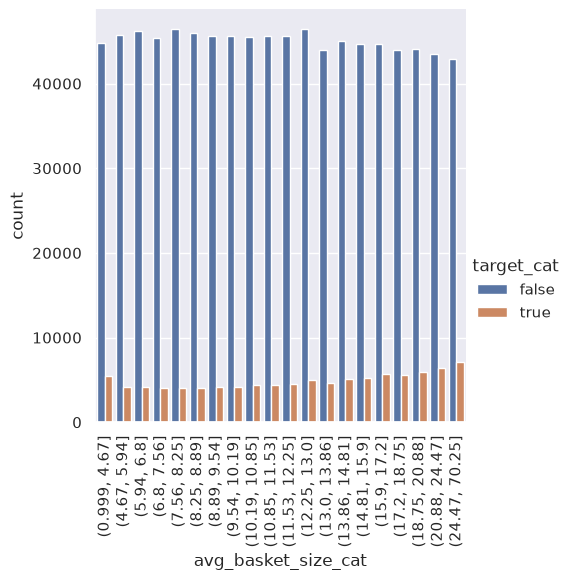

In [16]:
segmenting_data('avg_basket_size',20)

target_cat                                  false      true
unique_product_reorder_rate_percent_cat                    
(-0.001, 14.04]                          0.919184  0.080816
(14.04, 19.7]                            0.912208  0.087792
(19.7, 23.74]                            0.910643  0.089357
(23.74, 27.03]                           0.908785  0.091215
(27.03, 29.84]                           0.912403  0.087597
(29.84, 32.35]                           0.910998  0.089002
(32.35, 34.58]                           0.911396  0.088604
(34.58, 36.68]                           0.914845  0.085155
(36.68, 38.68]                           0.912051  0.087949
(38.68, 40.6]                            0.912117  0.087883
(40.6, 42.5]                             0.911072  0.088928
(42.5, 44.44]                            0.904921  0.095079
(44.44, 46.42]                           0.909589  0.090411
(46.42, 48.39]                           0.902249  0.097751
(48.39, 50.55]                          

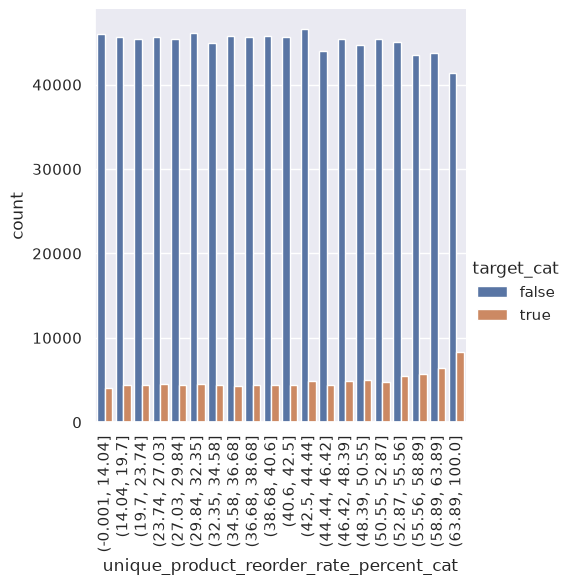

In [17]:
segmenting_data('unique_product_reorder_rate_percent',20)

target_cat                          false      true
user_product_reordered_rate_cat                    
(-0.001, 0.5]                    0.940219  0.059781
(0.5, 0.667]                     0.845460  0.154540
(0.667, 0.75]                    0.811710  0.188290
(0.75, 0.8]                      0.786463  0.213537
(0.8, 0.833]                     0.767943  0.232057
(0.833, 0.857]                   0.744177  0.255823
(0.857, 0.889]                   0.722616  0.277384
(0.889, 0.923]                   0.684331  0.315669
(0.923, 0.99]                    0.576457  0.423543


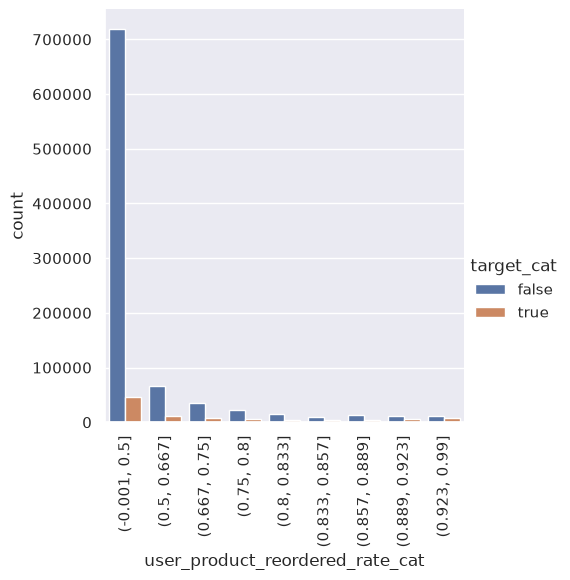

In [18]:
segmenting_data('user_product_reordered_rate',50)

target_cat                             false      true
product_reorder_x_total_orders_cat                    
(-0.001, 1.5]                       0.949828  0.050172
(1.5, 4.0]                          0.732078  0.267922
(4.0, 7.0]                          0.795722  0.204278
(7.0, 10.5]                         0.815452  0.184548
(10.5, 14.5]                        0.834936  0.165064
(14.5, 20.0]                        0.849985  0.150015
(20.0, 28.0]                        0.860615  0.139385
(28.0, 42.0]                        0.863699  0.136301
(42.0, 98.0]                        0.867209  0.132791


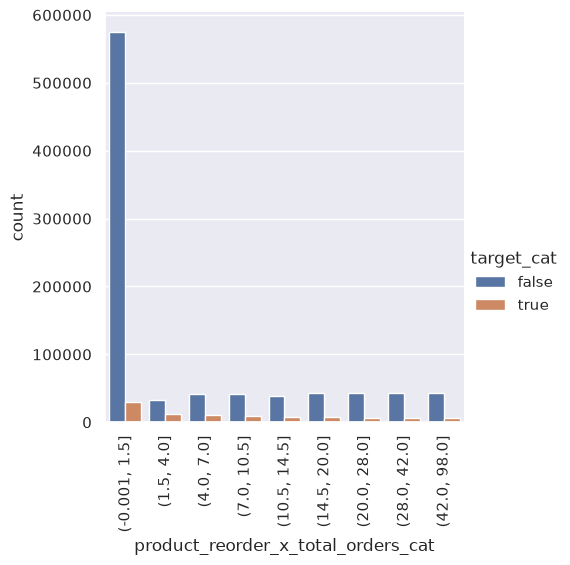

In [19]:
df_clean['product_reorder_x_total_orders'] = df_clean['user_product_reordered_rate'] * df_clean['total_prior_orders']
segmenting_data('product_reorder_x_total_orders', 20)

target_cat                            false      true
product_reorder_x_basket_size_cat                    
(-0.001, 1.11]                     0.952476  0.047524
(1.11, 3.99]                       0.865685  0.134315
(3.99, 5.267]                      0.873510  0.126490
(5.267, 6.447]                     0.865499  0.134501
(6.447, 7.72]                      0.851394  0.148606
(7.72, 9.215]                      0.836424  0.163576
(9.215, 11.165]                    0.814394  0.185606
(11.165, 14.36]                    0.781557  0.218443
(14.36, 55.304]                    0.719284  0.280716


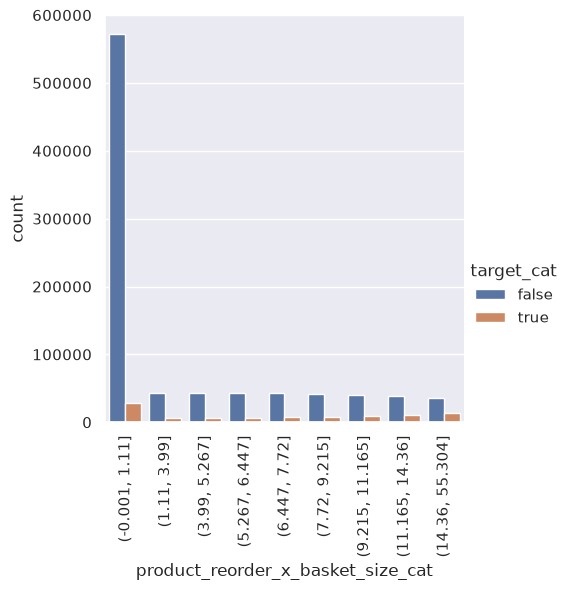

In [20]:
df_clean['product_reorder_x_basket_size'] = df_clean['user_product_reordered_rate'] * df_clean['avg_basket_size']
segmenting_data('product_reorder_x_basket_size', 20)

target_cat                              false      true
reorder_x_total_orders_x_basket_cat                    
(-0.001, 6.5]                        0.952228  0.047772
(6.5, 45.0]                          0.747840  0.252160
(45.0, 78.78]                        0.796604  0.203396
(78.78, 119.98]                      0.821682  0.178318
(119.98, 172.498]                    0.834551  0.165449
(172.498, 244.032]                   0.844683  0.155317
(244.032, 350.0]                     0.860177  0.139823
(350.0, 537.901]                     0.860700  0.139300
(537.901, 3539.442]                  0.844520  0.155480


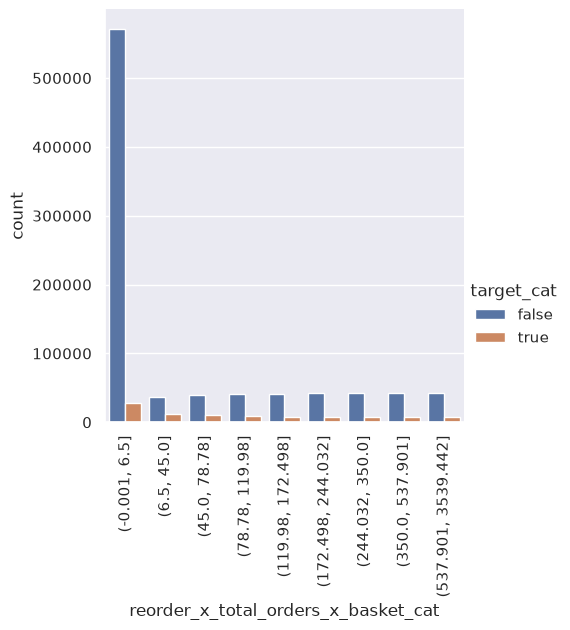

In [21]:
df_clean['reorder_x_total_orders_x_basket'] = df_clean['user_product_reordered_rate'] * df_clean['avg_basket_size'] * df_clean['total_prior_orders']
segmenting_data('reorder_x_total_orders_x_basket', 20)

target_cat                   false      true
purchase_cycle_score_cat                    
(-0.001, 0.193]           0.930180  0.069820
(0.193, 0.731]            0.752269  0.247731
(0.731, 1.241]            0.710531  0.289469
(1.241, 3.0]              0.761662  0.238338


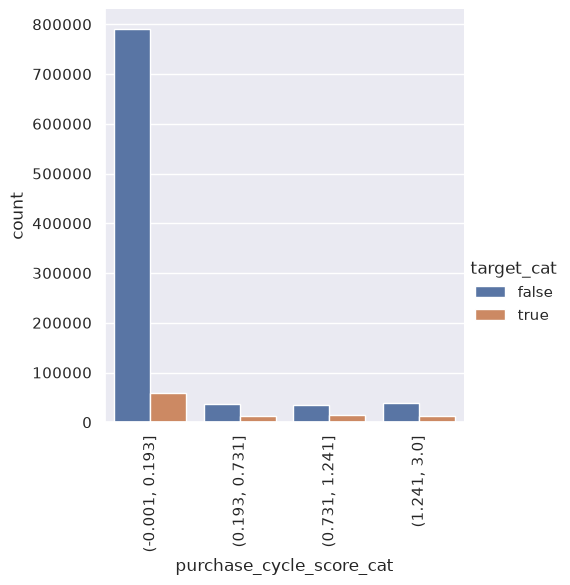

In [22]:
segmenting_data('purchase_cycle_score',20)

In [23]:
df_clean['product_x_department_score']=df_clean['product_score'] * df_clean['department_score']

In [24]:
df_clean['product_all_products'] = df_clean['user_product_purchase_count']/df_clean['total_product_purchases'] * 100

In [25]:
bins = [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,1,1.2,1.4,1.6,1.8,2,2.5,3,3.5,4,5,6,8,10,14,20,30,45,60,80,100]
df_clean['product_all_products_cat']=pd.cut(df_clean['product_all_products'],bins=bins,include_lowest=True)
table_product_all_products = pd.crosstab(
    index =df_clean['product_all_products_cat'],
    columns=df_clean['target_cat'],
    normalize = 'index'
)

In [26]:
df_clean['product_all_products_score'] = df_clean['product_all_products_cat'].map(table_product_all_products['true']).astype(float)

In [27]:
bins = [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,1]
df_clean['product_purchases_per_order_cat']=pd.cut(df_clean['product_purchases_per_order'],bins=bins,include_lowest=True)

table_product_purchases_per_order = pd.crosstab(
    index =df_clean['product_purchases_per_order_cat'],
    columns=df_clean['target_cat'],
    normalize = 'index'
)

df_clean['product_purchases_per_order_score'] = df_clean['product_purchases_per_order_cat'].map(table_product_purchases_per_order['true']).astype(float)

In [28]:
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score, f1_score

In [29]:
from sklearn.ensemble import RandomForestClassifier

In [30]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier

In [31]:
bins=[0,1,2,3,4,5,6,7,8,9,10,12,15,20,30,45,60,94]

df_clean['user_product_purchase_count_cat']=pd.cut(df_clean['user_product_purchase_count'],bins=bins,include_lowest=True)
table_user_product_purchase_count = pd.crosstab(
    index = df_clean['user_product_purchase_count_cat'],
    columns = df_clean['target_cat'],
    normalize='index'
)

In [32]:
df_clean['user_product_purchase_count_score']=df_clean['user_product_purchase_count_cat'].map(table_user_product_purchase_count['true']).astype(float)

In [33]:
bins=[0,1,2,3,4,5,6,7,8,9,10,12,15,20,30,45,60,80,100]

df_clean['user_reorder_rate_percent_cat']=pd.cut(df_clean['user_reorder_rate_percent'],bins=bins,include_lowest=True)

In [34]:
df_clean['reorder_x_prod_purchase_count'] = df_clean['user_reorder_rate_percent'] * df_clean['user_product_purchase_count_score']

In [35]:
df_clean['reorder_x_prod_purchase_count_cat'] = pd.cut(df_clean['reorder_x_prod_purchase_count'],bins=20,include_lowest=True)
table_reorder_x_prod_purchase_count = pd.crosstab(
    index = df_clean['reorder_x_prod_purchase_count_cat'],
    columns = df_clean['target_cat'],
    normalize='index'
)

In [36]:
df_clean['reorder_x_prod_purchase_count_score'] =df_clean['reorder_x_prod_purchase_count_cat'].map(
    table_reorder_x_prod_purchase_count["true"]).astype(float)

In [37]:
df_clean["prod_ratio_x_reorder_x_prod_purchase"]=df_clean['product_all_products_score']*df_clean['reorder_x_prod_purchase_count_score']
df_clean["prod_pur_per_order_score_x_reorder_x_prod_purchase"]=df_clean['product_purchases_per_order_score'] * df_clean['reorder_x_prod_purchase_count_score']

In [38]:
df_clean['orders_since_last_purchase_cat']=pd.cut(df_clean['orders_since_last_purchase'],bins=10,include_lowest=True)

In [39]:
df_clean['products_since_last_purchase_cat']=pd.cut(df_clean['products_since_last_purchase'],bins=20,include_lowest=True)

In [40]:
bins=[0,5,10,20,30,40,50,60,70,80,90,100,200,300,400,500,600,700,800,900,1000,2000,3000,4000,5000,6000,7000,8000,9000,10000,
     20000,30000,40000,300000]

df_clean['products_x_orders_since_last_purchase'] = df_clean['products_since_last_purchase']*df_clean['orders_since_last_purchase']
df_clean['products_x_orders_since_last_purchase_cat']=pd.cut(df_clean['products_x_orders_since_last_purchase'],bins=bins,include_lowest=True)
table_products_x_orders_since_last_purchase = pd.crosstab(
    index = df_clean['products_x_orders_since_last_purchase_cat'],
    columns = df_clean['target_cat'],
    normalize='index'
)

In [41]:
df_clean['products_x_orders_since_last_purchase_score'] = df_clean['products_x_orders_since_last_purchase_cat'].map(
    table_products_x_orders_since_last_purchase["true"]).astype(float)

In [42]:
import time

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GroupShuffleSplit

In [43]:
df_clean['target_rate_x_last_3_orders']=df_clean['product_target_rate'] * df_clean['last_3_orders']
df_clean['target_rate_x_last_6_orders']=df_clean['product_target_rate'] * df_clean['last_6_orders']
df_clean['target_rate_x_last_9_orders']=df_clean['product_target_rate'] * df_clean['last_9_orders']
df_clean['target_rate_x_last_9_orders']=df_clean['product_target_rate'] * df_clean['last_9_orders']
df_clean['user_product_affinity']=df_clean['user_product_avg_days_since_prior_order'] / df_clean['prod_avg_days_since_prior_order']
df_clean['product_user_affinity']=df_clean['user_product_avg_days_since_prior_order'] / df_clean['user_avg_days_since_prior_order']


In [44]:
features_random2 = [
 'aisle_reordered_rate',
 'department_reordered_rate',
 'days_since_prior_order',
 'product_purchases_per_order',
 'total_prior_orders',
 'total_product_purchases',
 'total_reordered_purchases',
 'avg_basket_size',
 'user_reorder_rate_percent',
 'user_avg_days_since_prior_order',
 'user_stddev_days_since_prior_order',
 'percentage_of_orders_including_product',
 'user_product_purchase_count',
 'last_product_order_number',
 'orders_since_last_purchase',
 'products_since_last_purchase',
 'user_product_reordered_rate',
 'last_3_orders',
 'last_6_orders',
 'last_9_orders',
 'last_12_orders',
 'prod_avg_days_since_prior_order',
 'prod_stddev_days_since_prior_order',
 'product_reordered_rate',
 'user_product_avg_days_since_prior_order',
 'user_product_stddev_days_since_prior_order',
 'department_score',
 'product_target_rate',
 'product_score',
 'purchase_cycle_score',
 'product_reorder_x_total_orders',
 'product_reorder_x_basket_size',
 'reorder_x_total_orders_x_basket',
 'product_x_department_score',
 'product_all_products_score',
 'product_purchases_per_order_score',
 'user_product_purchase_count_score',
 'reorder_x_prod_purchase_count',
 'reorder_x_prod_purchase_count_score',
 'prod_ratio_x_reorder_x_prod_purchase',
 'prod_pur_per_order_score_x_reorder_x_prod_purchase',
 'products_x_orders_since_last_purchase',
 'products_x_orders_since_last_purchase_score',
    'target_rate_x_last_3_orders',
    'target_rate_x_last_6_orders',
    'target_rate_x_last_9_orders',
    'user_product_affinity',
    'product_user_affinity'
]

features_random = [
 'user_id',
 'product_id',
 'aisle_id',
 'aisle_reordered_rate',
 'department_id',
 'department_reordered_rate',
 'days_since_prior_order',
 'product_purchases_per_order',
 'total_prior_orders',
 'total_product_purchases',
 'total_reordered_purchases',
 'avg_basket_size',
 'user_reorder_rate_percent',
 'unique_products_purchased',
 'unique_reordered_products',
 'unique_product_reorder_rate_percent',
 'user_aisle_reordered_rate',
 'user_avg_days_since_prior_order',
 'user_stddev_days_since_prior_order',
 'user_department_reordered_rate',
 'percentage_of_orders_including_product',
 'user_product_purchase_count',
 'last_product_order_number',
 'orders_since_last_purchase',
 'products_since_last_purchase',
 'user_product_reordered_rate',
 'last_3_orders',
 'last_6_orders',
 'last_9_orders',
 'last_12_orders',
 'prod_avg_days_since_prior_order',
 'prod_stddev_days_since_prior_order',
 'product_reordered_rate',
 'user_product_avg_days_since_prior_order',
 'user_product_stddev_days_since_prior_order',
 'department_score',
 'product_target_rate',
 'product_score',
 'purchase_cycle_score',
 'product_reorder_x_total_orders',
 'product_reorder_x_basket_size',
 'reorder_x_total_orders_x_basket',
 'product_x_department_score',
 'product_all_products',
 'product_all_products_score',
 'product_purchases_per_order_score',
 'user_product_purchase_count_score',
 'reorder_x_prod_purchase_count',
 'reorder_x_prod_purchase_count_score',
 'prod_ratio_x_reorder_x_prod_purchase',
 'prod_pur_per_order_score_x_reorder_x_prod_purchase',
 'products_x_orders_since_last_purchase',
 'products_x_orders_since_last_purchase_score',
        'target_rate_x_last_3_orders',
    'target_rate_x_last_6_orders',
    'target_rate_x_last_9_orders',
    'user_product_affinity',
    'product_user_affinity'
]

X = df_clean[features_random].copy()

y = df_clean["target_cat"].map({
    "true": 1,
    "false": 0,
})

groups = df_clean["user_id"]

In [45]:
split_test = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_valid_idx, test_idx = next(
    split_test.split(X, y, groups=groups)
)

X_train_valid = X.iloc[train_valid_idx]
y_train_valid = y.iloc[train_valid_idx]
groups_train_valid = groups.iloc[train_valid_idx]

X_test = X.iloc[test_idx]
y_test = y.iloc[test_idx]

In [46]:
split_valid = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=43
)

train_idx, valid_idx = next(
    split_valid.split(
        X_train_valid,
        y_train_valid,
        groups=groups_train_valid
    )
)

X_train = X_train_valid.iloc[train_idx]
y_train = y_train_valid.iloc[train_idx]

X_valid = X_train_valid.iloc[valid_idx]
y_valid = y_train_valid.iloc[valid_idx]

print("Train:", X_train.shape)
print("Validation:", X_valid.shape)
print("Test:", X_test.shape)

Train: (640662, 58)
Validation: (160410, 58)
Test: (198928, 58)


In [47]:
def objective(trial):

    model = RandomForestClassifier(
        n_estimators=trial.suggest_int(
            'n_estimators', 300 , 500, step=100
        ),
        max_depth=trial.suggest_int(
            "max_depth", 8, 20
        ),
        min_samples_split=trial.suggest_int(
            "min_samples_split", 2, 6
        ),
        min_samples_leaf=trial.suggest_int(
            "min_samples_leaf", 1, 6
        ),
        max_features=trial.suggest_categorical(
            "max_features", ["sqrt", "log2", 0.5]
        ),
        class_weight=trial.suggest_categorical(
            "class_weight",
            [None, "balanced", "balanced_subsample"]
        ),
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    y_valid_proba = model.predict_proba(X_valid)[:, 1]

    return average_precision_score(
        y_valid,
        y_valid_proba
    )

In [48]:
trials_number = 10

# 1. Tworzymy lub wczytujemy istniejący study z pliku SQLite
study_rf = optuna.create_study(
    study_name="my_rf_optimization",
    storage="sqlite:///optuna_rf.db",  # Utworzy plik w folderze roboczym
    load_if_exists=True,
    direction="maximize"
)

# 2. Wykonujemy optymalizację tylko wtedy, gdy nie ma jeszcze zrealizowanych prób
if len(study_rf.trials) < trials_number:
    study_rf.optimize(
        objective,
        n_trials=trials_number - len(study_rf.trials),
        show_progress_bar=True
    )

# 3. Te linie będą działać ZAWSZE (nawet po restarcie Jupytera)
print("Najlepszy Average Precision:", study_rf.best_value)
print("Najlepsze parametry:", study_rf.best_params)

[I 2026-08-28 19:03:08,372] Using an existing study with name 'my_rf_optimization' instead of creating a new one.


Najlepszy Average Precision: 0.4433931598557312
Najlepsze parametry: {'n_estimators': 300, 'max_depth': 12, 'min_samples_split': 4, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'class_weight': None}


In [49]:
from pathlib import Path

import joblib
from sklearn.ensemble import RandomForestClassifier


model_path = Path("models/random_forest.joblib")

if model_path.exists():
    model_rf = joblib.load(model_path)
    print("Wczytano zapisany model.")
else:
    model_path.parent.mkdir(parents=True, exist_ok=True)

    model_rf = RandomForestClassifier(
        **study_rf.best_params,
        random_state=42,
        n_jobs=-1
    )

    model_rf.fit(X_train, y_train)
    joblib.dump(model_rf, model_path)

    print("Wytrenowano i zapisano nowy model.")

Wytrenowano i zapisano nowy model.


In [50]:
import joblib
from pathlib import Path

models_dir = Path("models")
models_dir.mkdir(exist_ok=True)

model_path = models_dir / "random_forest.joblib"

joblib.dump(model_rf, model_path)

print(f"Model zapisano w: {model_path}")

Model zapisano w: models/random_forest.joblib


In [51]:
y_valid_proba = model_rf.predict_proba(X_valid)[:, 1]

precision, recall, thresholds = precision_recall_curve(
    y_valid,
    y_valid_proba
)

f1_scores = (
    2 * precision[:-1] * recall[:-1]
    / (precision[:-1] + recall[:-1] + 1e-9)
)

best_index = np.argmax(f1_scores)
best_threshold = thresholds[best_index]

print("Najlepszy threshold:", best_threshold)
print("F1 validation:", f1_scores[best_index])

Najlepszy threshold: 0.21175132845162328
F1 validation: 0.4618556696133889


In [52]:
y_test_proba = model_rf.predict_proba(X_test)[:, 1]

y_test_pred = (
    y_test_proba >= best_threshold
).astype("int8")

In [53]:
print("\n RANDOM FOREST OPTUNA ")

print(f"Threshold:         {best_threshold:.4f}")
print(f"Accuracy:          {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Precision:         {precision_score(y_test, y_test_pred):.4f}")
print(f"Recall:            {recall_score(y_test, y_test_pred):.4f}")
print(f"F1-Score:          {f1_score(y_test, y_test_pred):.4f}")
print(f"ROC-AUC:           {roc_auc_score(y_test, y_test_proba):.4f}")
print(
    f"Average Precision: "
    f"{average_precision_score(y_test, y_test_proba):.4f}"
)

print("\nRaport klasyfikacji:")
print(
    classification_report(
        y_test,
        y_test_pred,
        digits=4
    )
)


 RANDOM FOREST OPTUNA 
Threshold:         0.2118
Accuracy:          0.8762
Precision:         0.4011
Recall:            0.5424
F1-Score:          0.4612
ROC-AUC:           0.8541
Average Precision: 0.4539

Raport klasyfikacji:
              precision    recall  f1-score   support

           0     0.9485    0.9123    0.9301    179496
           1     0.4011    0.5424    0.4612     19432

    accuracy                         0.8762    198928
   macro avg     0.6748    0.7273    0.6956    198928
weighted avg     0.8950    0.8762    0.8843    198928



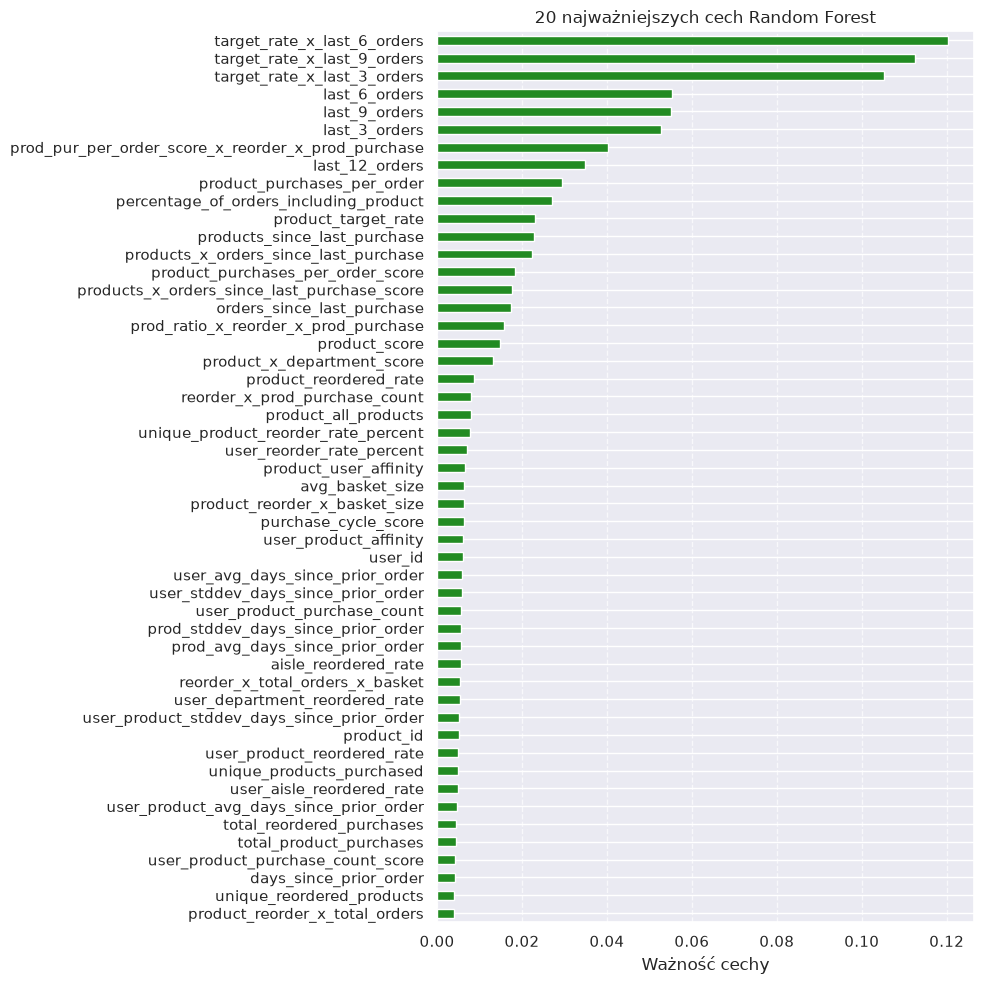

In [54]:
importances_rf = pd.Series(
    model_rf.feature_importances_,
    index=features_random,
).sort_values()

plt.figure(figsize=(10, 10))

importances_rf.tail(50).plot(
    kind="barh",
    color="forestgreen",
)

plt.title("20 najważniejszych cech Random Forest")
plt.xlabel("Ważność cechy")
plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.7,
)

plt.tight_layout()
plt.show()

In [55]:
# Kopia cech ze zbioru testowego
result_rf = X_test.copy()

# Używamy .to_numpy(), aby przypisać wartości według kolejności wierszy,
# niezależnie od oryginalnych indeksów Pandas
result_rf["actual"] = y_test.to_numpy()
result_rf["predict"] = y_test_pred
result_rf["proba_1"] = y_test_proba

# Odległość przewidywanego prawdopodobieństwa od prawdziwej klasy
result_rf["error_score"] = np.abs(
    result_rf["actual"] - result_rf["proba_1"]
)

# 1 oznacza poprawną klasyfikację, a 0 błędną
result_rf["is_correct"] = (
    result_rf["actual"] == result_rf["predict"]
).astype("int8")

columns_to_compare = [
    *features_random,
    "actual",
    "predict",
    "proba_1",
    "error_score",
    "is_correct"
]

k = min(50_000, len(result_rf))

comparison_rf = pd.DataFrame({
    "all_data": (
        result_rf[columns_to_compare]
        .mean()
    ),
    f"best_{k}_predictions": (
        result_rf
        .nsmallest(k, "error_score")[columns_to_compare]
        .mean()
    ),
    f"worst_{k}_predictions": (
        result_rf
        .nlargest(k, "error_score")[columns_to_compare]
        .mean()
    )
})

comparison_rf.round(2)

,all_data,best_50000_predictions,worst_50000_predictions
user_id,102348.52,102108.43,102686.63
product_id,25472.64,25129.68,25704.12
aisle_id,71.07,69.00,71.51
aisle_reordered_rate,0.56,0.49,0.61
department_id,10.22,11.20,9.45
...,...,...,...
actual,0.10,0.00,0.39
predict,0.13,0.00,0.52
proba_1,0.10,0.01,0.27
error_score,0.14,0.01,0.43


In [56]:
result_cm = X_test.copy()

result_cm["actual"] = y_test.to_numpy()
result_cm["predict"] = y_test_pred
result_cm["proba_1"] = y_test_proba

conditions = [
    (
        (result_cm["actual"] == 1)
        & (result_cm["predict"] == 1)
    ),
    (
        (result_cm["actual"] == 0)
        & (result_cm["predict"] == 0)
    ),
    (
        (result_cm["actual"] == 0)
        & (result_cm["predict"] == 1)
    ),
    (
        (result_cm["actual"] == 1)
        & (result_cm["predict"] == 0)
    )
]

choices = [
    "TP_correct_reorders",
    "TN_correct_non_reorders",
    "FP_false_alarms",
    "FN_missed_reorders"
]

result_cm["group"] = np.select(
    conditions,
    choices,
    default="other"
)

comparison_matrix = (
    result_cm
    .groupby("group")[features_random]
    .mean()
    .T
)

comparison_matrix.round(2)

group,FN_missed_reorders,FP_false_alarms,TN_correct_non_reorders,TP_correct_reorders
user_id,104255.55,102517.63,102216.66,102535.76
product_id,25801.54,25550.39,25459.60,25281.70
aisle_id,71.64,71.20,71.06,70.54
aisle_reordered_rate,0.58,0.63,0.54,0.63
department_id,9.63,9.32,10.39,9.43
department_reordered_rate,0.59,0.62,0.56,0.62
days_since_prior_order,14.67,15.60,13.38,14.95
product_purchases_per_order,0.17,0.38,0.11,0.48
total_prior_orders,19.43,18.20,26.28,18.25
total_product_purchases,245.24,244.14,313.16,252.78


In [57]:
from pathlib import Path

import joblib
import numpy as np
import optuna
from optuna.trial import TrialState

from sklearn.metrics import average_precision_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


# Konfiguracja

RANDOM_STATE = 42

N_MODEL_TRIALS = 15
N_BLEND_TRIALS = 100

MODEL_DIR = Path("./models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

RF_MODEL_PATH = MODEL_DIR / "random_forest.joblib"
XGB_MODEL_PATH = MODEL_DIR / "xgboost.joblib"
LGBM_MODEL_PATH = MODEL_DIR / "lightgbm.joblib"
BLEND_PATH = MODEL_DIR / "model_blend.joblib"

OPTUNA_DB_PATH = Path("optuna_boost.db")
OPTUNA_STORAGE = f"sqlite:///{OPTUNA_DB_PATH.resolve().as_posix()}"


# Funkcje pomocnicze

def completed_trials_count(study):
    """Zwraca liczbę poprawnie zakończonych prób Optuny."""
    return sum(
        trial.state == TrialState.COMPLETE
        for trial in study.trials
    )


def run_missing_trials(study, objective, required_trials):
    """
    Uruchamia tylko brakujące próby.

    Jeżeli badanie ma już odpowiednią liczbę zakończonych prób,
    optymalizacja zostaje pominięta.
    """
    completed = completed_trials_count(study)
    missing = max(0, required_trials - completed)

    if missing > 0:
        print(
            f"\nBadanie '{study.study_name}': "
            f"wykonano {completed}, brakuje {missing} prób."
        )

        study.optimize(
            objective,
            n_trials=missing,
            gc_after_trial=True,
            show_progress_bar=True,
        )
    else:
        print(
            f"\nBadanie '{study.study_name}' zawiera już "
            f"{completed} zakończonych prób. "
            "Optymalizacja zostaje pominięta."
        )


def get_positive_class_probability(model, X):
    """
    Pobiera prawdopodobieństwo klasy pozytywnej oznaczonej jako 1.

    Funkcja nie zakłada, że klasa 1 zawsze znajduje się
    w drugiej kolumnie predict_proba().
    """
    probabilities = model.predict_proba(X)
    classes = np.asarray(model.classes_)

    positive_class_positions = np.flatnonzero(classes == 1)

    if len(positive_class_positions) != 1:
        raise ValueError(
            f"Model {type(model).__name__} nie zawiera dokładnie "
            "jednej klasy pozytywnej oznaczonej wartością 1. "
            f"Dostępne klasy: {classes.tolist()}"
        )

    positive_class_index = positive_class_positions[0]

    return probabilities[:, positive_class_index]


# Funkcje celu dla XGBoost i LightGBM

def xgboost_objective(trial):
    params = {
        "n_estimators": trial.suggest_int(
            "n_estimators", 400, 600, step=100
        ),
        "max_depth": trial.suggest_int(
            "max_depth", 3, 12
        ),
        "learning_rate": trial.suggest_float(
            "learning_rate", 0.01, 0.2, log=True
        ),
        "min_child_weight": trial.suggest_float(
            "min_child_weight", 1.0, 15.0
        ),
        "subsample": trial.suggest_float(
            "subsample", 0.6, 1.0
        ),
        "colsample_bytree": trial.suggest_float(
            "colsample_bytree", 0.6, 1.0
        ),
        "gamma": trial.suggest_float(
            "gamma", 0.0, 5.0
        ),
        "reg_alpha": trial.suggest_float(
            "reg_alpha", 1e-8, 10.0, log=True
        ),
        "reg_lambda": trial.suggest_float(
            "reg_lambda", 1e-8, 10.0, log=True
        ),
        "eval_metric": "logloss",
        "tree_method": "hist",
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
    }

    model = XGBClassifier(**params)
    model.fit(X_train, y_train)

    probabilities = get_positive_class_probability(model, X_valid)

    return average_precision_score(y_valid, probabilities)


def lightgbm_objective(trial):
    params = {
        "n_estimators": trial.suggest_int(
            "n_estimators", 400, 600, step=100
        ),
        "num_leaves": trial.suggest_int(
            "num_leaves", 15, 127
        ),
        "max_depth": trial.suggest_int(
            "max_depth", -1, 15
        ),
        "learning_rate": trial.suggest_float(
            "learning_rate", 0.01, 0.2, log=True
        ),
        "min_child_samples": trial.suggest_int(
            "min_child_samples", 10, 100
        ),
        "subsample": trial.suggest_float(
            "subsample", 0.6, 1.0
        ),
        "colsample_bytree": trial.suggest_float(
            "colsample_bytree", 0.6, 1.0
        ),
        "reg_alpha": trial.suggest_float(
            "reg_alpha", 1e-8, 10.0, log=True
        ),
        "reg_lambda": trial.suggest_float(
            "reg_lambda", 1e-8, 10.0, log=True
        ),

        # Bez subsample_freq LightGBM może nie używać subsample.
        "subsample_freq": 1,

        "class_weight": "balanced",
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
        "verbosity": -1,
    }

    model = LGBMClassifier(**params)
    model.fit(X_train, y_train)

    probabilities = get_positive_class_probability(model, X_valid)

    return average_precision_score(y_valid, probabilities)


# Wczytanie Random Forest

if not RF_MODEL_PATH.exists():
    raise FileNotFoundError(
        f"Nie znaleziono modelu Random Forest: {RF_MODEL_PATH}"
    )

model_rf = joblib.load(RF_MODEL_PATH)

print(f"Wczytano Random Forest z pliku: {RF_MODEL_PATH}")


# Utworzenie lub wczytanie badań Optuny

xgboost_study = optuna.create_study(
    study_name="xgboost_optimization",
    storage=OPTUNA_STORAGE,
    direction="maximize",
    load_if_exists=True,
    sampler=optuna.samplers.TPESampler(
        seed=RANDOM_STATE
    ),
)

lightgbm_study = optuna.create_study(
    study_name="lightgbm_optimization",
    storage=OPTUNA_STORAGE,
    direction="maximize",
    load_if_exists=True,
    sampler=optuna.samplers.TPESampler(
        seed=RANDOM_STATE
    ),
)



# Uruchomienie brakujących prób

run_missing_trials(
    study=xgboost_study,
    objective=xgboost_objective,
    required_trials=N_MODEL_TRIALS,
)

run_missing_trials(
    study=lightgbm_study,
    objective=lightgbm_objective,
    required_trials=N_MODEL_TRIALS,
)


# Najlepsze parametry

xgboost_params = {
    **xgboost_study.best_params,
    "eval_metric": "logloss",
    "tree_method": "hist",
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
}

lightgbm_params = {
    **lightgbm_study.best_params,
    "subsample_freq": 1,
    "class_weight": "balanced",
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "verbosity": -1,
}

print("\nNajlepsze parametry XGBoost:")
print(xgboost_params)

print("\nNajlepsze parametry LightGBM:")
print(lightgbm_params)


# Utworzenie i trenowanie modeli

model_xgb = XGBClassifier(**xgboost_params)
model_lgbm = LGBMClassifier(**lightgbm_params)

print("\nTrenowanie XGBoost...")
model_xgb.fit(X_train, y_train)

print("Trenowanie LightGBM...")
model_lgbm.fit(X_train, y_train)


# Zapis modeli

joblib.dump(model_xgb, XGB_MODEL_PATH)
joblib.dump(model_lgbm, LGBM_MODEL_PATH)

print(f"\nZapisano XGBoost: {XGB_MODEL_PATH}")
print(f"Zapisano LightGBM: {LGBM_MODEL_PATH}")


# Predykcje modeli na zbiorze walidacyjnym

rf_valid_probabilities = get_positive_class_probability(
    model_rf,
    X_valid,
)

xgb_valid_probabilities = get_positive_class_probability(
    model_xgb,
    X_valid,
)

lgbm_valid_probabilities = get_positive_class_probability(
    model_lgbm,
    X_valid,
)


# Optymalizacja wag mieszaniny

def blend_objective(trial):
    """
    Optymalizuje trzy wagi, których suma zawsze wynosi 1.

    Najpierw wybierana jest waga Random Forest.
    Pozostała część jest dzielona pomiędzy XGBoost i LightGBM.
    """
    weight_rf = trial.suggest_float(
        "weight_rf",
        0.0,
        1.0,
    )

    weight_xgb_share = trial.suggest_float(
        "weight_xgb_share",
        0.0,
        1.0,
    )

    remaining_weight = 1.0 - weight_rf

    weight_xgb = remaining_weight * weight_xgb_share
    weight_lgbm = remaining_weight * (1.0 - weight_xgb_share)

    blended_probabilities = (
        weight_rf * rf_valid_probabilities
        + weight_xgb * xgb_valid_probabilities
        + weight_lgbm * lgbm_valid_probabilities
    )

    return average_precision_score(
        y_valid,
        blended_probabilities,
    )


blend_study = optuna.create_study(
    study_name="model_blend_optimization",
    storage=OPTUNA_STORAGE,
    direction="maximize",
    load_if_exists=True,
    sampler=optuna.samplers.TPESampler(
        seed=RANDOM_STATE
    ),
)

run_missing_trials(
    study=blend_study,
    objective=blend_objective,
    required_trials=N_BLEND_TRIALS,
)


# Pobranie najlepszych wag

best_blend_params = blend_study.best_params

weight_rf = best_blend_params["weight_rf"]
weight_xgb_share = best_blend_params["weight_xgb_share"]

remaining_weight = 1.0 - weight_rf

weight_xgb = remaining_weight * weight_xgb_share
weight_lgbm = remaining_weight * (1.0 - weight_xgb_share)

blend_weights = {
    "random_forest": float(weight_rf),
    "xgboost": float(weight_xgb),
    "lightgbm": float(weight_lgbm),
}


# Zapis informacji o mieszaninie

blend_data = {
    "weights": blend_weights,
    "model_paths": {
        "random_forest": str(RF_MODEL_PATH),
        "xgboost": str(XGB_MODEL_PATH),
        "lightgbm": str(LGBM_MODEL_PATH),
    },
    "metric": "average_precision_score",
    "positive_class": 1,
}

joblib.dump(blend_data, BLEND_PATH)

print(f"\nZapisano konfigurację mieszaniny: {BLEND_PATH}")


# Obliczenie końcowych wyników

blended_valid_probabilities = (
    blend_weights["random_forest"] * rf_valid_probabilities
    + blend_weights["xgboost"] * xgb_valid_probabilities
    + blend_weights["lightgbm"] * lgbm_valid_probabilities
)

rf_score = average_precision_score(
    y_valid,
    rf_valid_probabilities,
)

xgb_score = average_precision_score(
    y_valid,
    xgb_valid_probabilities,
)

lgbm_score = average_precision_score(
    y_valid,
    lgbm_valid_probabilities,
)

blend_score = average_precision_score(
    y_valid,
    blended_valid_probabilities,
)


# Wyświetlenie wyników

print("\n" + "=" * 60)
print("WYNIKI NA ZBIORZE WALIDACYJNYM")
print("=" * 60)

print(f"Random Forest AP: {rf_score:.6f}")
print(f"XGBoost AP:       {xgb_score:.6f}")
print(f"LightGBM AP:      {lgbm_score:.6f}")
print(f"Mieszanka AP:     {blend_score:.6f}")

print("\nOptymalne wagi mieszaniny:")
print(f"Random Forest: {blend_weights['random_forest']:.6f}")
print(f"XGBoost:       {blend_weights['xgboost']:.6f}")
print(f"LightGBM:      {blend_weights['lightgbm']:.6f}")

print(
    "Suma wag:      "
    f"{sum(blend_weights.values()):.6f}"
)

[I 2026-08-28 19:04:06,147] Using an existing study with name 'xgboost_optimization' instead of creating a new one.
[I 2026-08-28 19:04:06,190] Using an existing study with name 'lightgbm_optimization' instead of creating a new one.


Wczytano Random Forest z pliku: models/random_forest.joblib

Badanie 'xgboost_optimization' zawiera już 15 zakończonych prób. Optymalizacja zostaje pominięta.

Badanie 'lightgbm_optimization' zawiera już 15 zakończonych prób. Optymalizacja zostaje pominięta.

Najlepsze parametry XGBoost:
{'n_estimators': 400, 'max_depth': 8, 'learning_rate': 0.02703190387828653, 'min_child_weight': 8.592401719558296, 'subsample': 0.7737425087025646, 'colsample_bytree': 0.99417629801423, 'gamma': 3.895158223316646, 'reg_alpha': 8.865750663232216, 'reg_lambda': 9.710662705281733, 'eval_metric': 'logloss', 'tree_method': 'hist', 'random_state': 42, 'n_jobs': -1}

Najlepsze parametry LightGBM:
{'n_estimators': 500, 'num_leaves': 119, 'max_depth': 0, 'learning_rate': 0.017987863473362915, 'min_child_samples': 14, 'subsample': 0.7301321323053057, 'colsample_bytree': 0.7554709158757928, 'reg_alpha': 2.7678419414850017e-06, 'reg_lambda': 0.28749982347407854, 'subsample_freq': 1, 'class_weight': 'balanced', 'ra

[I 2026-08-28 19:04:37,185] Using an existing study with name 'model_blend_optimization' instead of creating a new one.



Badanie 'model_blend_optimization' zawiera już 100 zakończonych prób. Optymalizacja zostaje pominięta.

Zapisano konfigurację mieszaniny: models/model_blend.joblib

WYNIKI NA ZBIORZE WALIDACYJNYM
Random Forest AP: 0.452652
XGBoost AP:       0.457248
LightGBM AP:      0.455672
Mieszanka AP:     0.457270

Optymalne wagi mieszaniny:
Random Forest: 0.000318
XGBoost:       0.518940
LightGBM:      0.480742
Suma wag:      1.000000


In [58]:
import joblib
X_new = X_test

model_rf = joblib.load("./models/random_forest.joblib")
model_xgb = joblib.load("./models/xgboost.joblib")
model_lgbm = joblib.load("./models/lightgbm.joblib")

blend_data = joblib.load("./models/model_blend.joblib")
weights = blend_data["weights"]

rf_probabilities = get_positive_class_probability(model_rf, X_new)
xgb_probabilities = get_positive_class_probability(model_xgb, X_new)
lgbm_probabilities = get_positive_class_probability(model_lgbm, X_new)

final_probabilities = (
    weights["random_forest"] * rf_probabilities
    + weights["xgboost"] * xgb_probabilities
    + weights["lightgbm"] * lgbm_probabilities
)

final_predictions = (final_probabilities >= 0.5).astype(int)

In [59]:
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)

# Optymalny threshold z krzywej precision-recall
precision, recall, thresholds = precision_recall_curve(
    y_valid,
    blended_valid_probabilities,
)

f1_values = (
    2 * precision[:-1] * recall[:-1]
    / (precision[:-1] + recall[:-1] + 1e-10)
)

threshold = thresholds[np.argmax(f1_values)]

# Zamiana prawdopodobieństw na klasy
predictions = (
    blended_valid_probabilities >= threshold
).astype(int)

# Wyniki
print(f"Threshold:         {threshold:.4f}")
print(f"Accuracy:          {accuracy_score(y_valid, predictions):.4f}")
print(f"Precision:         {precision_score(y_valid, predictions):.4f}")
print(f"Recall:            {recall_score(y_valid, predictions):.4f}")
print(f"F1-Score:          {f1_score(y_valid, predictions):.4f}")
print(f"ROC-AUC:           {roc_auc_score(y_valid, blended_valid_probabilities):.4f}")
print(f"Average Precision: {average_precision_score(y_valid, blended_valid_probabilities):.4f}")

print("\nRaport klasyfikacji:")
print(
    classification_report(
        y_valid,
        predictions,
        digits=4,
        zero_division=0,
    )
)

Threshold:         0.4550
Accuracy:          0.8759
Precision:         0.4084
Recall:            0.5448
F1-Score:          0.4668
ROC-AUC:           0.8553
Average Precision: 0.4573

Raport klasyfikacji:
              precision    recall  f1-score   support

           0     0.9477    0.9126    0.9298    144417
           1     0.4084    0.5448    0.4668     15993

    accuracy                         0.8759    160410
   macro avg     0.6780    0.7287    0.6983    160410
weighted avg     0.8939    0.8759    0.8836    160410



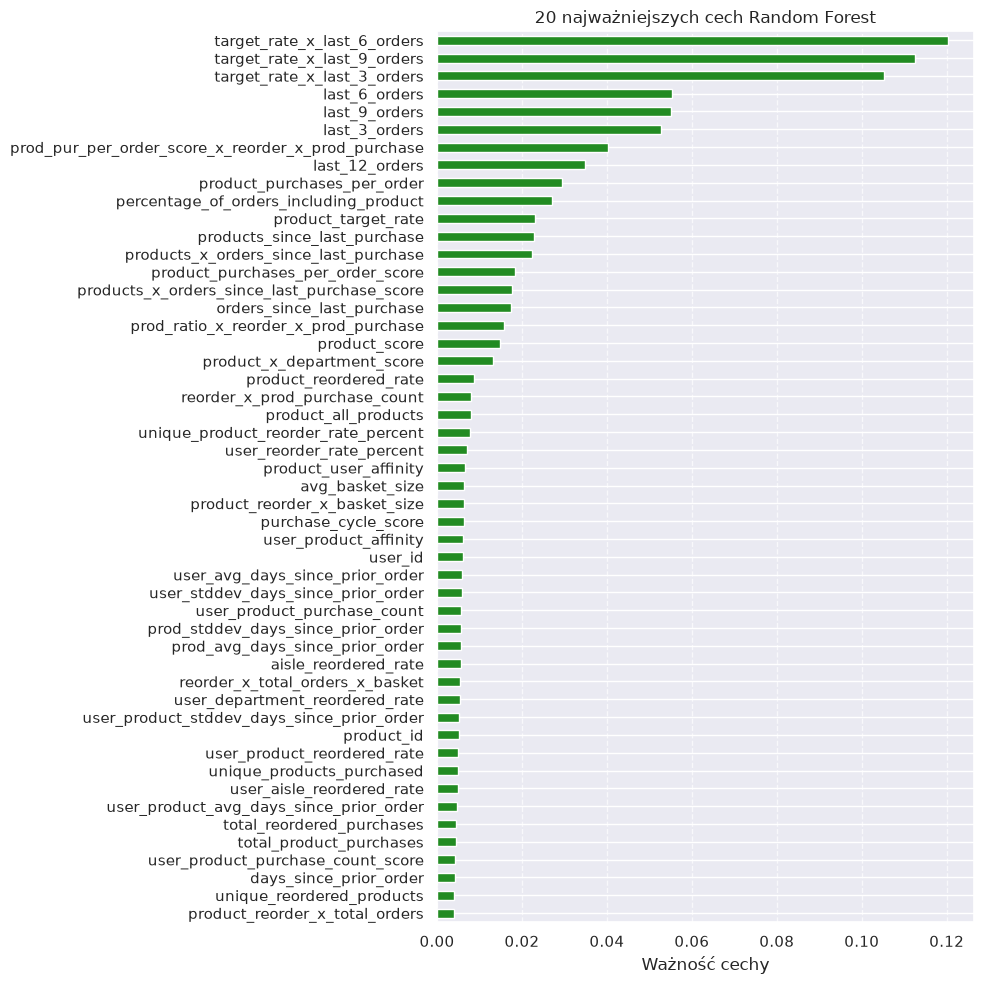

In [60]:
importances_rf = pd.Series(
    model_rf.feature_importances_,
    index=features_random,
).sort_values()

plt.figure(figsize=(10, 10))

importances_rf.tail(50).plot(
    kind="barh",
    color="forestgreen",
)

plt.title("20 najważniejszych cech Random Forest")
plt.xlabel("Ważność cechy")
plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.7,
)

plt.tight_layout()
plt.show()

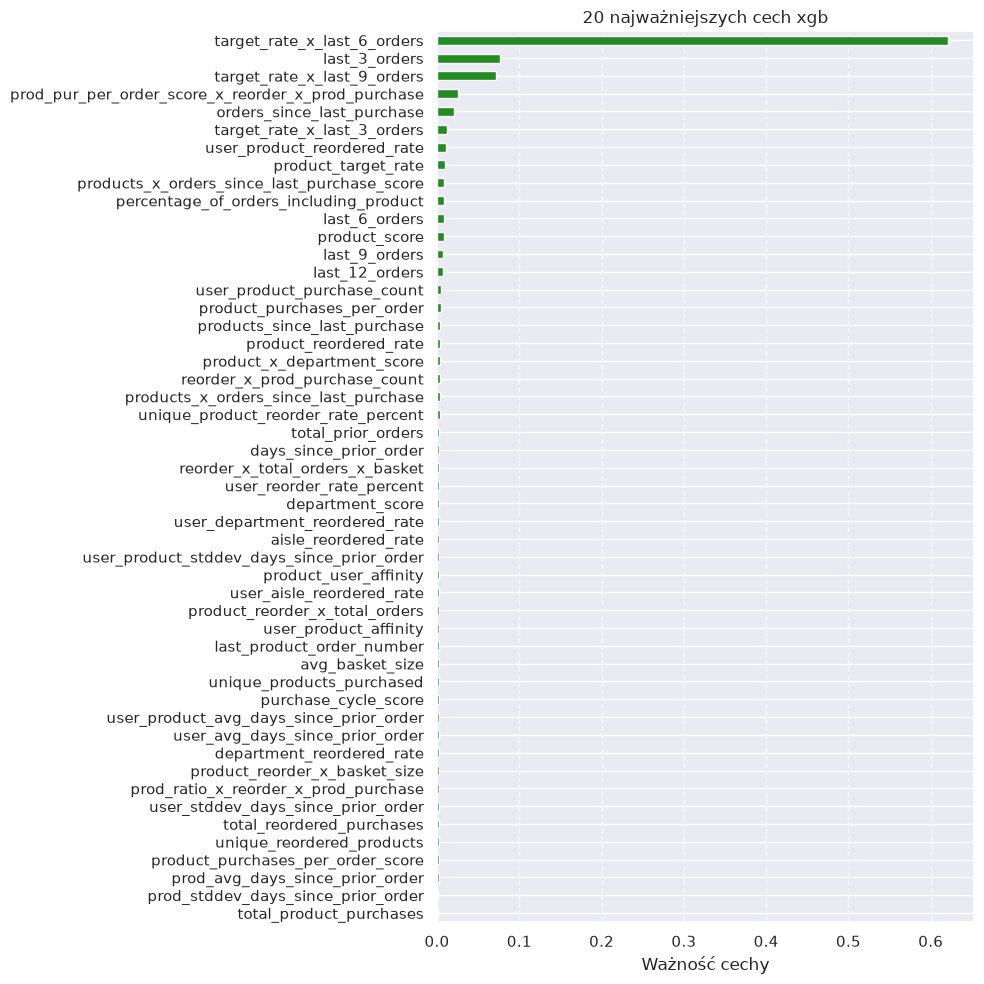

In [61]:
importances_xgb = pd.Series(
    model_xgb.feature_importances_,
    index=features_random,
).sort_values()

plt.figure(figsize=(10, 10))

importances_xgb.tail(50).plot(
    kind="barh",
    color="forestgreen",
)

plt.title("20 najważniejszych cech xgb")
plt.xlabel("Ważność cechy")
plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.7,
)

plt.tight_layout()
plt.show()

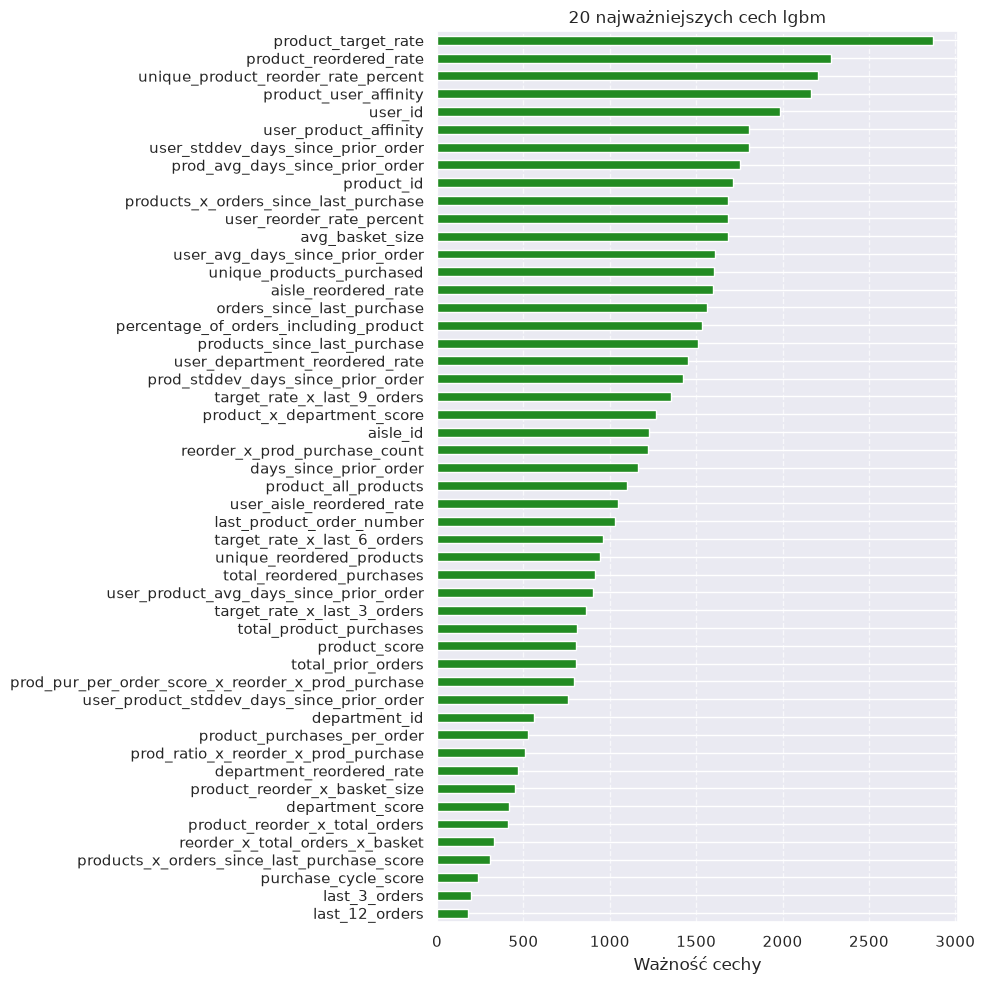

In [62]:
importances_lgbm = pd.Series(
    model_lgbm.feature_importances_,
    index=features_random,
).sort_values()

plt.figure(figsize=(10, 10))

importances_lgbm.tail(50).plot(
    kind="barh",
    color="forestgreen",
)

plt.title("20 najważniejszych cech lgbm")
plt.xlabel("Ważność cechy")
plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.7,
)

plt.tight_layout()
plt.show()